#Codeathon 3: AI Chatbot Generation with LLMs
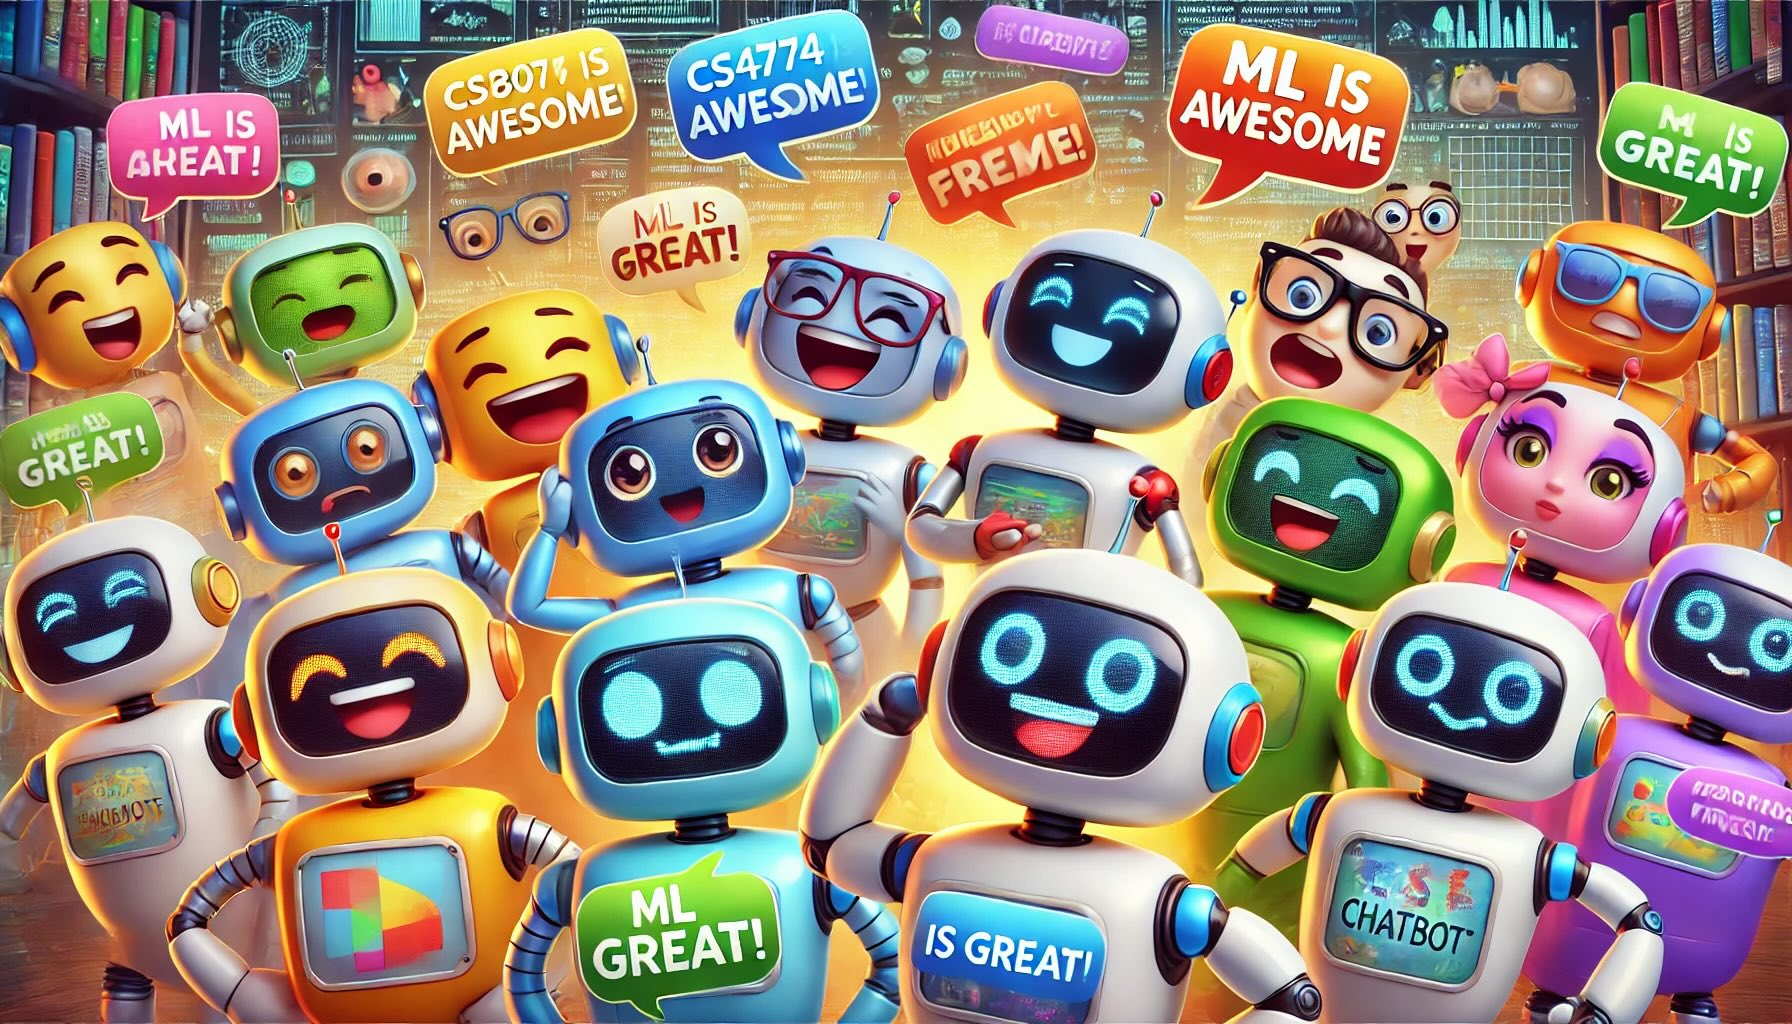
Alan Turing once posed the question, "Can machines think?" Today, chatbots powered by large language models (LLMs) are among the most sophisticated examples of machines engaging in human-like conversation. For this Codeathon, your task is to leverage an LLM to build a chatbot that can understand and respond intelligently to user queries. This chatbot will explore natural language processing, sequence modeling, and language generation fundamentals.

In this codeathon, you'll implement at least two out of three leading LLMs—OpenAI GPT, Meta LLaMA, and Google Gemini—to build your chatbot. You'll then analyze the unique characteristics and performance of each model, iterating with fine-tuning to see how the models evolve in response quality.

* **Design**: Your task is to connect and configure the LLMs and implement them in a chatbot that can handle structured, engaging conversations. You will observe and analyze differences between the models in handling conversations. You'll also fine-tune the model to improve response quality.

* **Implementation**: To get you started, you can use the code provided in the template. You'll integrate each model via API, compare responses, and implement a chatbot-to-chatbot loop where the two models "talk" to each other for a fixed number of exchanges. Fine-tune the models using a small/large dataset to see how their responses improve. Finally, implement a benchmark system that ranks the performance of each LLMs based on a standardized test, helping you compare the effectiveness of each model.


To make it easier for you, some code has been provided to help you connect with the APIs and process the data. You may modify it to fit your needs. Please submit the .ipynb file via UVA Canvas in the following format: **yourComputingID_codeathon_3.ipynb**


**Important Note**: Make sure your submission contains the outputs as TAs will not be able to directly run your code due to API security.

## 1. Dependencies
**Objective**: Set up the necessary environment and install dependencies to run the models.

*   Install Necessary Libraries: Download and install packages such as transformers, torch, and openai.
* Important Note: Use a T4 or equivalent GPU in Colab for optimal performance, as some functions require GPU access.

In [ ]:
# Install the OpenAI library for interacting with OpenAI's GPT models
!pip install openai
# Install the Google Generative AI library for interacting with Google Gemini models
!pip install -q -U google-generativeai
# Install Hugging Face Transformers, PyTorch, and Accelerate for working with various language models
# Install bitsandbytes for efficient model quantization
!pip install transformers torch accelerate bitsandbytes
# Upgrade Transformers to the latest version to ensure compatibility with recent models and features
!pip install --upgrade transformers
# (Optional) Install llama-recipes if you plan to fine-tune LLaMA models; also install ipywidgets for interactive widgets in Jupyter
# !pip install llama-recipes ipywidgets
# Install NLTK and rouge-score for evaluating text generation models using BLEU, ROUGE, and other language metrics
!pip install nltk rouge-score
# Install bert-score for evaluating model performance based on BERT embeddings for semantic similarity
!pip install bert-score

## 2. Models Setup
**Objective**: Explore at least two out of three models available in this Codeathon—GPT, LLaMA, and Gemini—and use them to perform text generation. Optional tasks include multimedia generation and analysis.

*   Check [Video](https://youtu.be/tD4eW3q02ZE?si=wqgrCeCL27TtKnoF) Tutorial for step-by-step API key setup corresponding to [ReadMe](https://docs.google.com/document/d/1S0wQ4bc88NMbjQJRrU86mRPxoi_urUL4uD5tTo-9KYQ/edit?usp=sharing).
* Model Initialization: Configure each model you choose through its API through corresponding Classes **(Gemini_Chatbot(), LLaMA_Chatbot(), OpenAI_Chatbot())** for generating responses.
* Make sure your chatbots could access the **entire chat history** instead of the just last reply and be able to **reset** the chat history. Print results to check!
* Text Generation: Test each model on basic text-generation tasks. Note the style, coherence, and clarity of their responses.
* (Optional) Multimedia Support:

 * Audio Input: Test a model that can analyze audio input.
 * Image Input: Test a model that can analyze image input.
 * Generation: Use a model to generate image and audio output if possible.

Please Note: While Meta Llama and Google Gemini offer free models usage through APIs, OpenAI GPT is not free of charge. Check the Video for more information.

Official Documentations: [Google Gemini Documentation](https://ai.google.dev/api?authuser=2&lang=python), [OpenAI GPT Documentation](https://platform.openai.com/docs/overview), [Meta Llama Documentation](https://www.llama.com/docs/overview).








### Gemini

In [1]:
# Take Gemini as an example, you don't have to use it.
import google.generativeai as genai
# Get access to the colab secret key chain
from google.colab import userdata

# Example Set Up of the API key stored in Google Colab secret keys
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)

class Gemini_Chatbot:
    def __init__(self, system_prompt="You are a helpful assistant."):
        self.model = genai.GenerativeModel("gemini-1.5-flash") #choose your model here
        self.history = [{"role": "model", "parts": system_prompt}]
        self.system_prompt = system_prompt

    # To do: implment the convser function to return the gemini response for specific prompt you input.
    # Make sure to add the conversation to the chat history.

    def format_history(self):
        formatted = ""
        for entry in self.history:
            role = entry["role"].capitalize()
            content = entry["parts"]
            formatted += f"{role}: {content}\n"
        return formatted

    def converse(self, user_input):
        self.history.append({"role": "user", "parts": user_input})
        prompt = self.format_history()
        response = self.model.generate_content(prompt)
        self.history.append({"role": "model", "parts": response.text})
        return response.text

    # To do: implment reset function.
    def reset(self, system_prompt="You are a helpful assistant."):
        self.history = [{"role": "model", "parts": system_prompt}]
        self.system_prompt = system_prompt

    def print_history(self):
        for entry in self.history:
            role = entry["role"].capitalize()
            content = entry["parts"]
            print(f"{role}: {content}\n")

# Test your implmentation!
gemini_chatbot = Gemini_Chatbot()

prompt = "Explain the concept of Generative AI."
response = gemini_chatbot.converse(prompt)
prompt = "How does it differ from traditional programming?"
response = gemini_chatbot.converse(prompt)
print("Conversation History:\n")
gemini_chatbot.print_history()

gemini_chatbot.reset()
print("\nConversation history has been reset.")
print("\nCurrent Conversation History after Reset:\n")
gemini_chatbot.print_history()

Conversation History:

Model: You are a helpful assistant.

User: Explain the concept of Generative AI.

Model: Generative AI is a type of artificial intelligence that can create new content, rather than just analyzing or classifying existing data.  Instead of simply recognizing patterns, it *generates* them.  Think of it as AI that can be creative.

Here's a breakdown:

* **Input:** Generative AI models are trained on massive datasets. This could be text, images, audio, video, or even code.  The training process allows the model to learn the underlying patterns and structures within the data.

* **Process:**  The model uses this learned knowledge to generate new, original content that shares similar characteristics to the training data.  This process often involves complex mathematical techniques like neural networks, particularly deep learning models like GANs (Generative Adversarial Networks), VAEs (Variational Autoencoders), and diffusion models.

* **Output:** The output can take 

### Llama

In [ ]:
!pip install --upgrade transformers

In [2]:
import transformers
import torch
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from huggingface_hub import login
from google.colab import userdata

class LLaMA_Chatbot:
    def __init__(self, system_prompt="You are a helpful assistant.", model_id="meta-llama/Llama-3.2-1B-Instruct"):
        my_secret_key = userdata.get('HF_TOKEN')
        login(token=my_secret_key)

        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type='nf4',
            bnb_4bit_compute_dtype=torch.bfloat16
        )

        self.tokenizer = AutoTokenizer.from_pretrained(model_id)
        self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            model_id,
            quantization_config=bnb_config,
            device_map='auto'
        )

        self.text_generator = transformers.pipeline(
            "text-generation",
            model=self.model,
            tokenizer=self.tokenizer,
            max_new_tokens=1024
        )

        self.history = [{"role": "system", "content": system_prompt}]

    # To do: implment the convser function to return the llama response for specific prompt you input.
    # Make sure to add the conversation to the chat history.
    # You are welcome to use format_history() function here.
    def converse(self, user_input):
        self.history.append({"role": "user", "content": user_input})
        prompt = self.format_history()
        response = self.text_generator(prompt)[0]['generated_text']
        actual_reply = response[len(prompt):].strip()

        for delimiter in ["System:", "User:"]:
            if delimiter in actual_reply:
                actual_reply = actual_reply.split(delimiter, 1)[0].strip()

        if actual_reply.startswith("Assistant:"):
            actual_reply = actual_reply[len("Assistant:"):].strip()

        self.history.append({"role": "assistant", "content": actual_reply})
        return actual_reply

    # To do: implment reset function.
    def reset(self, system_prompt="You are a helpful assistant."):
        self.history = [{"role": "system", "content": system_prompt}]

    def print_history(self):
        for entry in self.history:
            role = entry["role"].capitalize()
            content = entry["content"]
            print(f"{role}: {content}\n")

    def format_history(self):
        formatted = ""
        for message in self.history:
            role = message["role"].capitalize()
            content = message["content"]
            formatted += f"{role}: {content}\n"
        return formatted


# Test your implmentation!
llama_chatbot = LLaMA_Chatbot()

prompt = "Explain the concept of Generative AI."
response = llama_chatbot.converse(prompt)
prompt = "How does it differ from traditional programming?"
response = llama_chatbot.converse(prompt)

print("Conversation History:\n")
llama_chatbot.print_history()

llama_chatbot.reset()
print("\nConversation history has been reset.")
print("\nCurrent Conversation History after Reset:\n")
llama_chatbot.print_history()


Device set to use cuda:0


Conversation History:

System: You are a helpful assistant.

User: Explain the concept of Generative AI.

Assistant: Generative AI refers to a type of artificial intelligence that can create new content, such as images, videos, music, and text, that is indistinguishable from the original. This is achieved by training a machine learning model on a large dataset, which allows the model to learn patterns and relationships between the data and generate new content based on those patterns.

User: How does it differ from traditional programming?

Assistant: Generative AI differs from traditional programming in several ways. Firstly, it relies on complex algorithms and statistical models to generate new content, rather than relying on explicit programming. This means that the AI system does not have to write code to generate content, as it is generated automatically. Secondly, generative AI typically requires large amounts of training data to learn patterns and relationships, whereas traditio

### GPT

In [ ]:
from google.colab import userdata
from openai import OpenAI

class OpenAI_Chatbot:
    def __init__(self, system_prompt="You are a helpful assistant."):
        self.api_key = userdata.get("OpenAI_API")
        self.client = OpenAI(api_key=self.api_key)
        self.history = [{"role": "system", "content": system_prompt}]

    # To do: choose your model here and implment the convser function to return the gpt response for specific prompt you input.
    # Make sure to add the conversation to the chat history.
    def converse(self, user_input):

    # To do: implment reset function.
    def reset(self, system_prompt="You are a helpful assistant."):


    def print_history(self):
        for entry in self.history:
            role = entry["role"].capitalize()
            content = entry["content"]
            print(f"{role}: {content}\n")


# Test your implmentation!
openai_chatbot = OpenAI_Chatbot()

prompt = "Explain the concept of Generative AI."
response = openai_chatbot.converse(prompt)
prompt = "How does it differ from traditional programming?"
response = openai_chatbot.converse(prompt)

print("Conversation History:\n")
openai_chatbot.print_history()

openai_chatbot.reset()
print("\nConversation history has been reset.")
print("\nCurrent Conversation History after Reset:\n")
openai_chatbot.print_history()


## 3. Build Chatbots - Enable End-to-End Conversation
**Objective**: Develop at least two chatbots interface that enables end-to-end conversations.

* Implement a chatbot that can have a structured, multi-turn conversation with the user, generating responses in text. Implement at least two functions out of three **(gemini_chatbot(), llama_chatbot(), gpt_chatbot())**.
* Provide an option for users to exit the conversation whenever needed.
* Perform at least **5** rounds of conversations.
* Hint: You can call your implemented functions from Step 2 Model Setup here.

### Gemini Chatbot

In [ ]:
def gemini_chatbot():
    chatbot = Gemini_Chatbot()
    print("Welcome to the Google Gemini Chatbot! Type 'exit' to end the chat.\n")

    while True:
        user_input = input("You: ")

        # To do: Check if user wants to exit, if so, provide exit option.
        if user_input.lower() == "exit":
            print("Goodbye!")
            chatbot.reset()
            break
        # To do: Generate response from Gemini model.

        response = chatbot.converse(user_input)

        print("Gemini:", response)

gemini_chatbot()

Welcome to the Google Gemini Chatbot! Type 'exit' to end the chat.

You: Hello
Gemini: Hello! How can I help you today?

You: How do I get a software engineering internship
Gemini: Getting a software engineering internship is a competitive process, but with the right approach, you can significantly increase your chances. Here's a breakdown of how to do it:

**1. Build Your Skills:**

* **Programming Languages:**  Master at least one or two popular languages like Python, Java, C++, JavaScript, or Go.  Focus on one to become proficient before branching out.
* **Data Structures and Algorithms:** This is crucial.  Practice solving problems on platforms like LeetCode, HackerRank, Codewars, and others.  Understanding these concepts is vital for technical interviews.
* **Version Control (Git):**  Learn Git and GitHub.  Almost all software development involves version control.
* **Databases:** Familiarity with SQL and relational databases is beneficial.  NoSQL databases are also increasingly i

### Llama Chatbot

In [ ]:
def llama_chatbot():
    chatbot = LLaMA_Chatbot()
    print("LLaMA Chatbot initialized! Type 'exit' to end the conversation.\n")

    while True:
        prompt = input("You: ")

        # To do: Check if user wants to exit, if so, provide exit option.
        if prompt.lower() == "exit":
            print("Goodbye!")
            chatbot.reset()
            break
        # To do: Generate response from LLaMA model.

        response = chatbot.converse(prompt)
        print("LLaMA:", response)

llama_chatbot()


LLaMA Chatbot initialized! Type 'exit' to end the conversation.

You: who are you?
LLaMA: I am a helpful assistant, a digital AI assistant designed to assist you with any questions, tasks, or concerns you may have. I'm here to help you with anything from setting reminders, sending messages, or even just providing information and guidance. What can I help you with today?
You: what would be an ideal vacation
LLaMA: An ideal vacation sounds like a wonderful idea! Let me help you plan a dreamy getaway.

To start, what type of vacation are you thinking of? Are you looking for relaxation, adventure, or something else? Do you have a specific destination in mind or are you open to suggestions?

Here are some questions to help narrow down the options:

1. How many people will be traveling with you?
2. What is your preferred travel style (e.g., beach, city, nature, cultural)?
3. Are there any specific activities or experiences you'd like to have during your vacation?
4. Are there any particular 

### GPT Chatbot

In [ ]:
def gpt_chatbot():
    chatbot = OpenAI_Chatbot()
    print("Welcome to the GPT Chatbot! Type 'exit' to end the chat.\n")
    while True:
        prompt = input("You: ")

        # To do: Check if user wants to exit, if so, provide exit option.

        # To do: Generate response from GPT model.

        print("GPT:", response)

gpt_chatbot()


## 4. Model-to-Model Conversation

* Select any two models from GPT, LLaMA, and Gemini, and configure them to have a conversation with each other (text only).

* Set Round Limit: Set a round limit for the conversation to ensure the exchange ends after a certain number of turns.

* Implement **model_conversation()** and test with a **10-round** limit to observe the interaction between two LLMs.

In [3]:
def model_conversation():

    # Initialize model instances, comment one model you didn't implement
    # openai_chatbot = OpenAI_Chatbot()
    gemini_chatbot = Gemini_Chatbot()
    llama_chatbot = LLaMA_Chatbot()

    # To do: add your model names and functions
    model_1_name = "LLaMA Chatbot"
    model_2_name = "Gemini Chatbot"

    model_1 = llama_chatbot
    model_2 = gemini_chatbot

    # Reset both models' histories at the start of the conversation
    model_1.reset()
    model_2.reset()

    print(f"\nStarting conversation between {model_1_name.upper()} and {model_2_name.upper()}.")

    # To do: set the number of rounds (10)
    num_rounds = 10
    # Initial prompt from the first model
    prompt = "Tell me about the Gilded Age in US History"
    print(f"{model_1_name.upper()}:\n", prompt)


    # To do: Implement your model-to-model conversation logic here
    for i in range(num_rounds):
        model_2_response = model_2.converse(prompt)
        print(f"{model_2_name.upper()}:\n", model_2_response)

        prompt = model_1.converse(model_2_response)
        print(f"{model_1_name.upper()}:\n", prompt)

    print("\n\nConversation ended.")

model_conversation()

Device set to use cuda:0



Starting conversation between LLAMA CHATBOT and GEMINI CHATBOT.
LLAMA CHATBOT:
 Tell me about the Gilded Age in US History
GEMINI CHATBOT:
 The Gilded Age, roughly spanning from the 1870s to the 1890s, was a period of immense economic growth and transformation in the United States, marked by rapid industrialization, urbanization, and immense wealth disparity.  The term "Gilded Age," coined by Mark Twain and Charles Dudley Warner, satirically highlights the era's superficial glitter masking deep social and economic problems.

Here's a breakdown of its key characteristics:

**Economic Growth and Industrialization:**

* **Rapid industrial expansion:**  The era witnessed unprecedented growth fueled by technological advancements (like the Bessemer process for steel production), abundant natural resources, and a burgeoning workforce.  Industries like steel, railroads, and oil boomed, creating immense fortunes for entrepreneurs known as "robber barons" or "captains of industry."
* **Railroad

## 5. Fine-Tune
**Objective**: Fine-tune one of the models to improve its response quality for a specific task. Expected prompt and answer provided. Compare the fine-tuned model with the untuned version to analyze improvements. For instruction, check the model's offical documentations.

* Text Fine-Tuning: Use the provided dataset **(fine_tune_10.csv)** and apply modifications (e.g., adjust prompts, learning rate, epochs) for better context understanding and response quality.
* Tuning example from Google Gemini: [Link](https://colab.research.google.com/github/google/generative-ai-docs/blob/main/site/en/gemini-api/docs/model-tuning/python.ipynb)
* Visualization: Use seaborn to visualize the relationship between epochs and loss during training. Example: [Plot Example](https://raw.githubusercontent.com/realAllenSong/example/refs/heads/main/example_plot.png)
* Save Fine-Tuned Model Class: Implement the Class for the fine-tuned model, followed the format from Step 2 Model Setup.

**IMPORTANT**: Fine-tuning for Llama is harder than the others in google colab. Consider using LoRA (Low-Rank Adaptation) for efficient fine-tuning. If you are certain that you want to try Llama Fine-tuning, there is a useful guideline: [Github](https://github.com/meta-llama/llama-recipes/blob/main/recipes/quickstart/finetuning/quickstart_peft_finetuning.ipynb).



In [4]:
# Download the sample dataset fine_tune_10.csv
!wget https://raw.githubusercontent.com/realAllenSong/example/refs/heads/main/fine_tuned_10.csv

--2024-12-05 19:21:25--  https://raw.githubusercontent.com/realAllenSong/example/refs/heads/main/fine_tuned_10.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3395 (3.3K) [text/plain]
Saving to: ‘fine_tuned_10.csv’

fine_tuned_10.csv   100%[===================>]   3.32K  --.-KB/s    in 0s      

2024-12-05 19:21:25 (65.7 MB/s) - ‘fine_tuned_10.csv’ saved [3395/3395]



In [8]:
import pandas as pd

data = pd.read_csv("fine_tuned_10.csv")
training_data = [{"text_input": row["Prompt"], "output": row["Response"]}
                 for i, row in data.iterrows()]

In [32]:
# Your fine-tuning starts here
name = 'wfs7bk-tuned-model-4'

operation = genai.create_tuned_model(
    source_model="models/gemini-1.5-flash-001-tuning",
    training_data=training_data,
    id=name,
    epoch_count=32,
    batch_size=8,
    learning_rate=0.001
)

<Axes: xlabel='epoch', ylabel='mean_loss'>

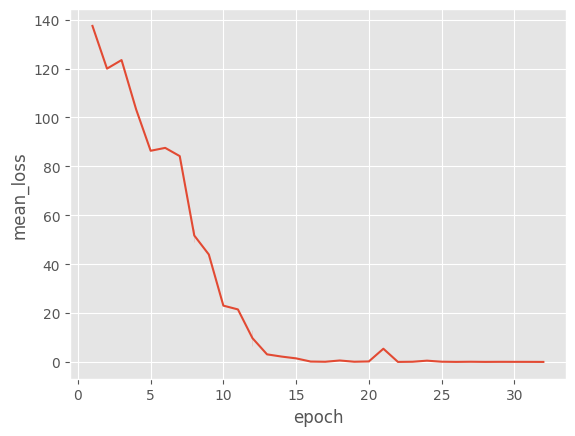

In [34]:
import seaborn as sns

model = operation.result()

snapshots = pd.DataFrame(model.tuning_task.snapshots)

sns.lineplot(data=snapshots, x = 'epoch', y='mean_loss')

In [35]:
# To do: implment your tuned chatbot class
# Hint: take advantage of your step 2 implementations!
'''
    def __init__(self, system_prompt="You are a helpful assistant."):
        self.model = genai.GenerativeModel("gemini-1.5-flash") #choose your model here
        self.history = [{"role": "model", "parts": system_prompt}]
        self.system_prompt = system_prompt

    # To do: implment the convser function to return the gemini response for specific prompt you input.
    # Make sure to add the conversation to the chat history.

    def format_history(self):
        formatted = ""
        for entry in self.history:
            role = entry["role"].capitalize()
            content = entry["parts"]
            formatted += f"{role}: {content}\n"
        return formatted

    def converse(self, user_input):
        self.history.append({"role": "user", "parts": user_input})
        prompt = self.format_history()
        response = self.model.generate_content(prompt)
        self.history.append({"role": "model", "parts": response.text})
        return response.text

    # To do: implment reset function.
    def reset(self, system_prompt="You are a helpful assistant."):
        self.history = [{"role": "model", "parts": system_prompt}]
        self.system_prompt = system_prompt

    def print_history(self):
        for entry in self.history:
            role = entry["role"].capitalize()
            content = entry["parts"]
            print(f"{role}: {content}\n")
'''

class Tuned_Chatbot:
    def __init__(self, system_prompt="You are a helpful assistant."):
        self.model = genai.GenerativeModel(model_name=f'tunedModels/wfs7bk-tuned-model-1') # add your tuned model here
        self.history = [{"role": "model", "parts": system_prompt}]
        self.system_prompt = system_prompt

    def format_history(self):
        formatted = ""
        for entry in self.history:
            role = entry["role"].capitalize()
            content = entry["parts"]
            formatted += f"{role}: {content}\n"
        return formatted

    def converse(self, user_input):
        self.history.append({"role": "user", "parts": user_input})
        prompt = self.format_history()
        response = self.model.generate_content(prompt)
        self.history.append({"role": "model", "parts": response.text})
        return response.text

    def reset(self, new_system_prompt=None):
        if new_system_prompt:
            self.system_prompt = new_system_prompt
        self.history = [{"role": "model", "parts": self.system_prompt}]

    def print_history(self):
        for entry in self.history:
            role = entry["role"].capitalize()
            content = entry["parts"]
            print(f"{role}: {content}\n")


## 6. Benchmark Comparison
**Objective**: Compare the your models's performance. Most of the code are provided.

* Set Up Benchmark Tests: Define evaluation metrics such as BLEU, ROUGE, and BERTScore.
* Output Scores and Improvement: Calculate benchmark scores and visualize the results. Check aggregate scores for models performance.
* Leatherboard: We will award extra credits to 10 students who generate highest aggregate score for their tuned model based on the current setup.(Ensure that the tuned model has faster inference time than the untuned version).


In [36]:
# Instantiate each model, comment one model you didn't implement.
# gpt_chatbot = OpenAI_Chatbot()
gemini_chatbot = Gemini_Chatbot()
llama_chatbot = LLaMA_Chatbot()
tuned_chatbot = Tuned_Chatbot()

# Define response functions for each model, comment one model you didn't implement.
'''
def gpt_response(prompt):
    return gpt_chatbot.converse(prompt)
'''

def gemini_response(prompt):
    return gemini_chatbot.converse(prompt)

def llama_response(prompt):
    return llama_chatbot.converse(prompt)

def tuned_response(prompt):
    return tuned_chatbot.converse(prompt)

Device set to use cuda:0


In [37]:
import time
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from bert_score import score as bert_score
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Load dataset
df_test = pd.read_csv("fine_tuned_10.csv")
sample_prompts = df_test["Prompt"].tolist()
reference_texts = df_test["Response"].tolist()

# Initialize ROUGE scorer
scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

results = []
# To do: delete the one you didn't use.
inference_times = {"Gemini": [], "LLaMA": [], "Tuned": []}

# Define the weights for each metric
weights = np.array([0.25, 0.25, 0.25, 0.25])  # Equal weight for each metric

# Define BLEU smoothing function
smoothing = SmoothingFunction().method1

# Loop over each prompt and compute scores for each model
for i, prompt in enumerate(sample_prompts):
    reference = reference_texts[i]
    prompt_scores = {"Prompt": prompt}

    # To do: delete the one you didn't use.
    for model_name, model_func in [
        ("Gemini", gemini_response),
        ("LLaMA", llama_response),
        ("Tuned", tuned_response)
    ]:
        try:
            # Get response and measure inference time
            start_time = time.time()
            response_text = model_func(prompt)
            end_time = time.time()
            inference_time = end_time - start_time
            inference_times[model_name].append(inference_time)

            # Calculate BLEU, ROUGE, and BERTScore
            bleu = sentence_bleu([reference.split()], response_text.split(), smoothing_function=smoothing)
            rouge = scorer.score(reference, response_text)
            rouge1 = rouge['rouge1'].fmeasure
            rougeL = rouge['rougeL'].fmeasure
            _, _, bert_f1 = bert_score([response_text], [reference], lang="en")

            # Store individual scores in the dictionary
            prompt_scores[f"{model_name} BLEU"] = bleu
            prompt_scores[f"{model_name} ROUGE-1"] = rouge1
            prompt_scores[f"{model_name} ROUGE-L"] = rougeL
            prompt_scores[f"{model_name} BERT F1"] = bert_f1.item()
            prompt_scores[f"{model_name} Inference Time (s)"] = inference_time
        except Exception as e:
            print(f"Error with {model_name} model for prompt '{prompt}': {e}")
            prompt_scores[f"{model_name} BLEU"] = np.nan
            prompt_scores[f"{model_name} ROUGE-1"] = np.nan
            prompt_scores[f"{model_name} ROUGE-L"] = np.nan
            prompt_scores[f"{model_name} BERT F1"] = np.nan
            prompt_scores[f"{model_name} Inference Time (s)"] = np.nan

    # Append the prompt scores to the results
    results.append(prompt_scores)

# Convert results to a DataFrame for display
df_results = pd.DataFrame(results)

final_scores = {}
# To do: Delete the one you didn't implement.
for model_name in ["Gemini", "LLaMA", "Tuned"]:
    model_scores = df_results[[f"{model_name} BLEU", f"{model_name} ROUGE-1", f"{model_name} ROUGE-L", f"{model_name} BERT F1"]]

    # Normalize scores using MinMax scaling (to bring all metrics between 0 and 1)
    scaler = MinMaxScaler()
    normalized_scores = scaler.fit_transform(model_scores.fillna(0))  # Fill NaNs with 0 for scaling

    # Calculate the weighted score for each example and then average for a final score
    weighted_scores = normalized_scores.dot(weights)
    final_scores[model_name] = weighted_scores.mean()  # Average across all examples

# Set display options for readability
pd.options.display.float_format = "{:,.4f}".format

# Display the individual scores table
print("\nIndividual Scores for Each Model and Prompt:")
display(df_results)

# Display the final aggregate scores in a table format
final_scores_df = pd.DataFrame({
    "Model": list(final_scores.keys()),
    "Final Aggregate Score": list(final_scores.values())
})
print("\nFinal Aggregate Scores for Each Model:")
display(final_scores_df)

# Display average inference times
average_inference_times = {model_name: np.nanmean(times) for model_name, times in inference_times.items()}
average_inference_df = pd.DataFrame(list(average_inference_times.items()), columns=["Model", "Average Inference Time (s)"])
print("\nAverage Inference Times for Each Model:")
display(average_inference_df)


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['ro


Individual Scores for Each Model and Prompt:


,Prompt,Gemini BLEU,Gemini ROUGE-1,Gemini ROUGE-L,Gemini BERT F1,Gemini Inference Time (s),LLaMA BLEU,LLaMA ROUGE-1,LLaMA ROUGE-L,LLaMA BERT F1,LLaMA Inference Time (s),Tuned BLEU,Tuned ROUGE-1,Tuned ROUGE-L,Tuned BERT F1,Tuned Inference Time (s)
0,Please describe to me the Computer Science Dep...,0.0010,0.1146,0.0764,0.8133,4.3380,0.0008,0.0524,0.0429,0.8017,41.1010,1.0000,1.0000,1.0000,1.0000,9.9596
1,How do you feel about Oppenheimer's accomplish...,0.0115,0.2492,0.1684,0.8614,2.4985,0.0045,0.1720,0.1290,0.8367,2.9374,0.8222,0.9062,0.9062,0.9661,10.0554
2,Who is the most recognizable alumnus of the Un...,0.0130,0.2985,0.1791,0.8665,0.9125,0.0152,0.2222,0.1746,0.8686,5.3206,0.5334,0.9123,0.8421,0.9641,1.3668
3,What are the long-term impacts of artificial i...,0.0017,0.1293,0.0733,0.8218,4.2404,0.0011,0.0654,0.0460,0.8195,42.7527,0.8280,0.9231,0.9231,0.9803,1.5147
4,What role does social media play in shaping pu...,0.0021,0.1012,0.0729,0.8207,4.6907,0.0007,0.0563,0.0328,0.8337,43.1990,0.8341,0.9333,0.9333,0.9747,8.7946
5,Should data privacy be considered a fundamenta...,0.0099,0.0917,0.0699,0.8088,4.1878,0.0066,0.0450,0.0402,0.8097,43.2581,1.0000,1.0000,1.0000,1.0000,8.3901
6,Is remote work a permanent shift in the workpl...,0.0020,0.0713,0.0629,0.8168,4.2592,0.0008,0.0456,0.0295,0.8244,44.3757,0.0296,0.3038,0.1519,0.8773,1.4903
7,Will artificial general intelligence (AGI) ult...,0.0076,0.0904,0.0629,0.8168,4.8146,0.0048,0.0603,0.0367,0.8157,47.3294,0.0632,0.2921,0.2472,0.8726,1.4429
8,How do you think the role of journalists will ...,0.0016,0.0849,0.0618,0.8206,5.2181,0.0012,0.0479,0.0353,0.8166,46.5034,1.0000,1.0000,1.0000,1.0000,5.4969
9,Generate a short story about a robot learning ...,0.0010,0.1005,0.0603,0.8001,3.8099,0.0026,0.1137,0.0806,0.8119,23.7309,0.0058,0.2301,0.1416,0.8376,4.1379



Final Aggregate Scores for Each Model:


,Model,Final Aggregate Score
0,Gemini,0.3066
1,LLaMA,0.2582
2,Tuned,0.6569



Average Inference Times for Each Model:


,Model,Average Inference Time (s)
0,Gemini,3.8970
1,LLaMA,34.0508
2,Tuned,5.2649


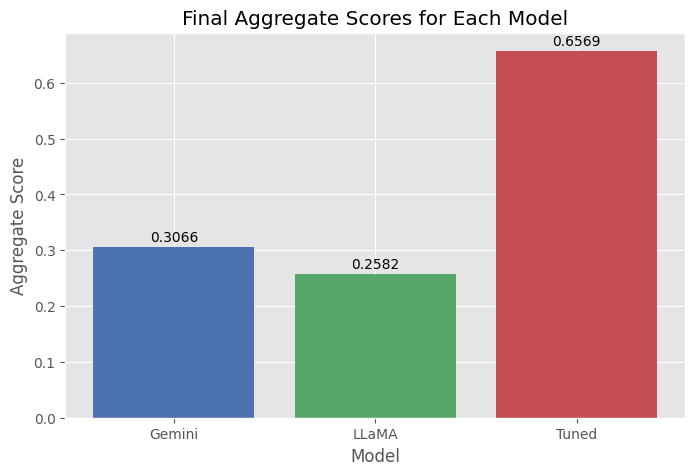

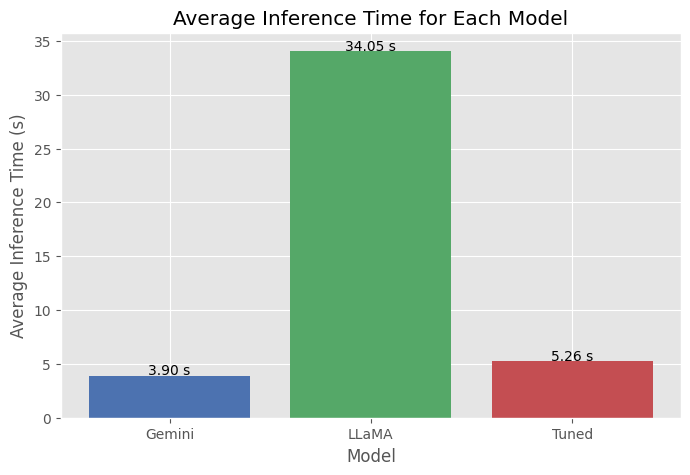

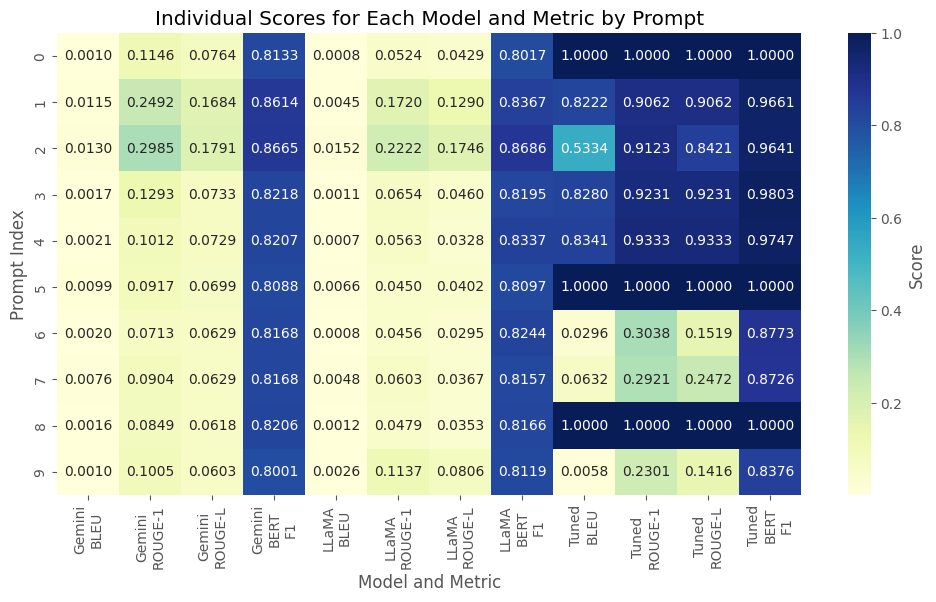

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# You can adjust the plotting as long as it prints meaningful results.

# Set style for better visuals
plt.style.use('ggplot')

# Visualization 1: Bar Chart for Final Aggregate Scores
plt.figure(figsize=(8, 5))
plt.bar(final_scores_df["Model"], final_scores_df["Final Aggregate Score"], color=['#4C72B0', '#55A868', '#C44E52'])
plt.title("Final Aggregate Scores for Each Model")
plt.xlabel("Model")
plt.ylabel("Aggregate Score")
for index, value in enumerate(final_scores_df["Final Aggregate Score"]):
    plt.text(index, value + 0.01, f"{value:.4f}", ha="center")
plt.show()

# Visualization 2: Bar Chart for Average Inference Times
plt.figure(figsize=(8, 5))
plt.bar(average_inference_df["Model"], average_inference_df["Average Inference Time (s)"], color=['#4C72B0', '#55A868', '#C44E52'])
plt.title("Average Inference Time for Each Model")
plt.xlabel("Model")
plt.ylabel("Average Inference Time (s)")
for index, value in enumerate(average_inference_df["Average Inference Time (s)"]):
    plt.text(index, value + 0.1, f"{value:.2f} s", ha="center")
plt.show()

# Visualization 3: Heatmap for Individual Scores by Model and Metric
# Prepare data for heatmap
score_cols = [col for col in df_results.columns if "BLEU" in col or "ROUGE" in col or "BERT F1" in col]
heatmap_data = df_results[score_cols].fillna(0)  # Fill NaNs with 0 for visualization
heatmap_data.columns = [col.replace(" ", "\n") for col in heatmap_data.columns]  # Add line breaks for readability

# Plot the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt=".4f", cbar_kws={'label': 'Score'})
plt.title("Individual Scores for Each Model and Metric by Prompt")
plt.xlabel("Model and Metric")
plt.ylabel("Prompt Index")
plt.show()


## 7. Experiment and Reflection

Congratulations on completing the Codeathon! Reflect on the experience of building and fine-tuning LLM-based chatbots. Briefly address the following:

* Experience and Challenges: Was it easy, fun, or challenging to set up and experiment with different LLMs? Describe any hurdles with API setup, inference times, or model tuning, and how you tackled them.

* Impact of Fine-Tuning: Reflect on how fine-tuning affected response quality—was there an improvement in coherence, relevance, or speed?

* Performance Metrics: Discuss the utility of metrics like BLEU, ROUGE, and BERTScore in assessing chatbot quality. Did using an aggregate score help in comparing models?

* User Engagement and Multimedia: If you tested multimedia features, did they add value to the chatbot experience?

Once you've reflected on these questions, consider experimenting further by setting up unique conversations or exploring how changes in configurations impact the responses.

Enjoy the possibilities with large language models!

In [ ]:
'''
It was fun implementing the LLMs, the Gemini chatbot in particular; however, LLaMA
was somewhat annoying to work with due to its high hardware demands and its slow
inference times. Working around these limitations just took patience and switching
Colab sessions. Fine tuning improved the coherence of the model responses by a
large amount and therefore could be seen as an overall success. Having metrics
to compare aggregate score was very helpful as it is somewhat harder to evaluate
the performance of generative AI models the way we evaluate other machine learning
models.
'''